### CODE CELL 1 : Importing Libraries and Detecting Suitable Hardware 
the following is responsible for importing the necessary libraries so that the code cells after this one are able to run efficiently

In [ ]:
import os
import cv2
import torch
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ultralytics import YOLO
import albumentations as A

if torch.cuda.is_available():
    device = 0
    gpu_name = torch.cuda.get_device_name(0)
    print(f"SUCCESS: High-Performance GPU Detected: {gpu_name}")
    print("Training will be fast.")
else:
    device = 'cpu'
    print("WARNING: No GPU detected. We are using the CPU.")
    print("Training will be extremely slow (hours or days).")

SUCCESS: High-Performance GPU Detected: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Training will be fast.


### CODE CELL 2 : creating the `yaml` file: 
- This file tells YOLO where the train, valid, and test are located.
- We define the absolute path to our dataset folder.
- The 'names' section is CRITICAL. It links the ID number (0, 1, 2) to the English name.
- These must match exactly what was used when the images were labeled.
- We save this text into a file called 'aircraft_defects.yaml'

In [2]:
# Pointing to your dataset inside the Ubuntu WSL environment
dataset_root = "/home/akash/Project Exhibition/YOLOv8 (New)/aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8"

yaml_content = f"""
path: {dataset_root}
train: train/images
val: valid/images
test: test/images

# Number of classes
nc: 5

# The 5 classes from the Roboflow 'aircraft-skin-defects-new-dataset'
names:
  0: crack
  1: dent
  2: missing-head
  3: paint-off
  4: scratch
"""

with open("aircraft_defects.yaml", "w") as f:
    f.write(yaml_content)

print("Map created: 'aircraft_defects.yaml'")
print(f"Pointing to dataset at: {dataset_root}")

Map created: 'aircraft_defects.yaml'
Pointing to dataset at: /home/akash/Project Exhibition/YOLOv8 (New)/aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8


### CODE CELL 3 : AUGMENTATION PIPELINE (The Multiplier)
- This defines the rules for creating the 8 variations of each image.
- We are sticking to the logic in the base paper: Flips and Rotations.
- Define the transformation pipeline

In [3]:
transform_pipeline = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels']
    )
)

print("Augmentation Pipeline Built.")
print("Strategy: Horizontal Flip, Vertical Flip, Rotation (90 deg).")
print("This matches the methodology to increase dataset diversity.")


Augmentation Pipeline Built.
Strategy: Horizontal Flip, Vertical Flip, Rotation (90 deg).
This matches the methodology to increase dataset diversity.


### CODE CELL 4: LOADING THE PRETRAINED MODEL
- We download the untainted, pre-trained YOLOv8 Small model.
- This model currently knows how to detect everyday objects (dogs, cars, people).
- We are going to wipe its memory of everyday objects and teach it aircraft specific images

In [4]:
model = YOLO('yolov8s.pt')  # Load the "Small" version as per Base Paper

print("Model loaded: YOLOv8s (Small).")
print("Status: Ready for Fine-Tuning.")

Model loaded: YOLOv8s (Small).
Status: Ready for Fine-Tuning.


### CODE CELL 5: TRAINING ; The Most Important Cell
- This starts the learning process
- Treats `data.yaml` as the guide
- We map the Base Paper's settings directly here
- For each epoch:
    - Loop through batches
    - Forward pass
    - Compute loss
    - Backpropagation
    - Update weights
    - Run validation
    - Compute metrics
    - Save logs

In [5]:
# CODE CELL 5: TRAINING
print("Starting YOLOv8 Fine-Tuning...")

results = model.train(
    # FIX 1: Point to the absolute path map we generated earlier
    data='aircraft_defects.yaml',
    
    # FIX 2: Prevent WSL System Freeze by limiting CPU threads
    workers=2,
    
    # Adjusted Learning Parameters
    epochs=50,      # Increased to allow thorough learning
    imgsz=640,      # 640 is standard and safe for an RTX 3050
    batch=4,        # 4 is a safe balance for 6GB of VRAM
    
    device=device,
    name='yolov8_aircraft_test',
    exist_ok=True,
    verbose=True
)

print("\nTraining Complete! Weights saved to runs/detect/yolov8_aircraft_test/weights/")

Starting YOLOv8 Fine-Tuning...
New https://pypi.org/project/ultralytics/8.4.24 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=aircraft_defects.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, 

### CODE CELL 6: PLOTTING THE LEARNING CURVES

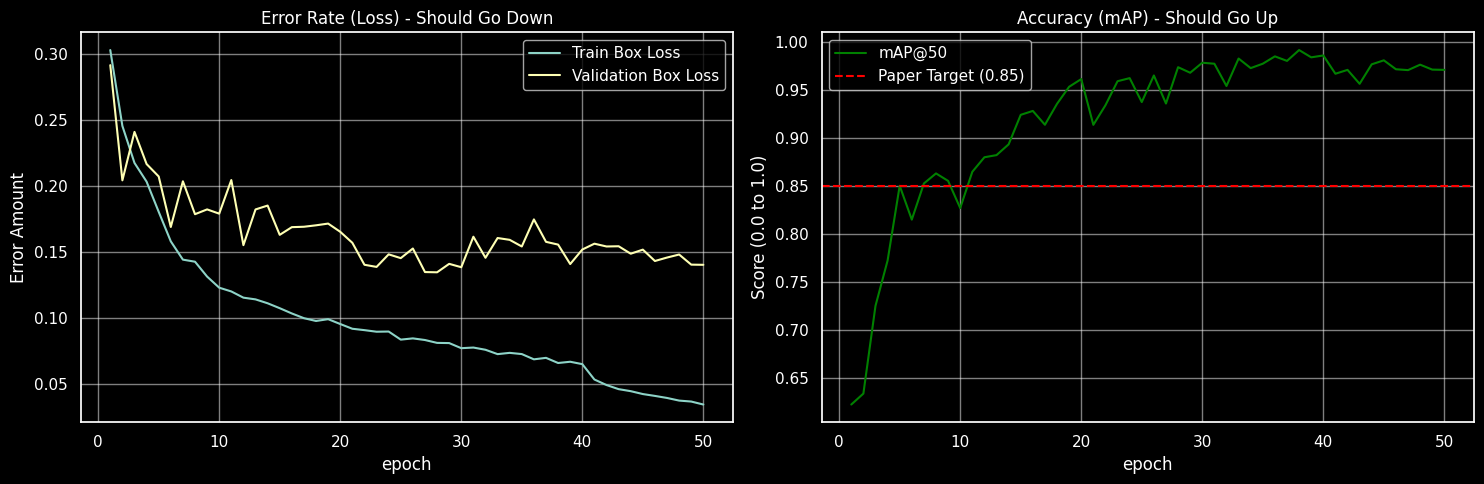

In [9]:
plt.style.use('dark_background')
plt.rcParams['grid.alpha'] = 0.5
%matplotlib inline

# FIX: Removed the extra 'runs/' from the path
results_path = 'runs/detect/yolov8_aircraft_test/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    # Strip any whitespace from column names just in case
    df.columns = df.columns.str.strip()

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # Graph 1: LOSS
    sns.lineplot(data=df, x='epoch', y='train/box_loss', label='Train Box Loss', ax=ax[0])
    sns.lineplot(data=df, x='epoch', y='val/box_loss', label='Validation Box Loss', ax=ax[0])
    ax[0].set_title("Error Rate (Loss) - Should Go Down")
    ax[0].set_ylabel("Error Amount")

    # Graph 2: mAP
    sns.lineplot(data=df, x='epoch', y='metrics/mAP50(B)', label='mAP@50', color='green', ax=ax[1])
    ax[1].set_title("Accuracy (mAP) - Should Go Up")
    ax[1].set_ylabel("Score (0.0 to 1.0)")
    ax[1].axhline(0.85, color='red', linestyle='--', label='Paper Target (0.85)')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print(f"Training is not finished or failed. No results.csv found at {results_path}")

### CODE CELL 7: PREDICTING ON NEW IMAGES
We take random images from the 'test' folder and let the AI diagnose them.


0: 1280x1280 1 missing-head, 37.6ms
1: 1280x1280 1 crack, 37.6ms
2: 1280x1280 1 missing-head, 37.6ms
Speed: 5.0ms preprocess, 37.6ms inference, 2.6ms postprocess per image at shape (1, 3, 1280, 1280)
Results saved to /home/akash/Project Exhibition/YOLOv8 (New)/runs/detect/predict


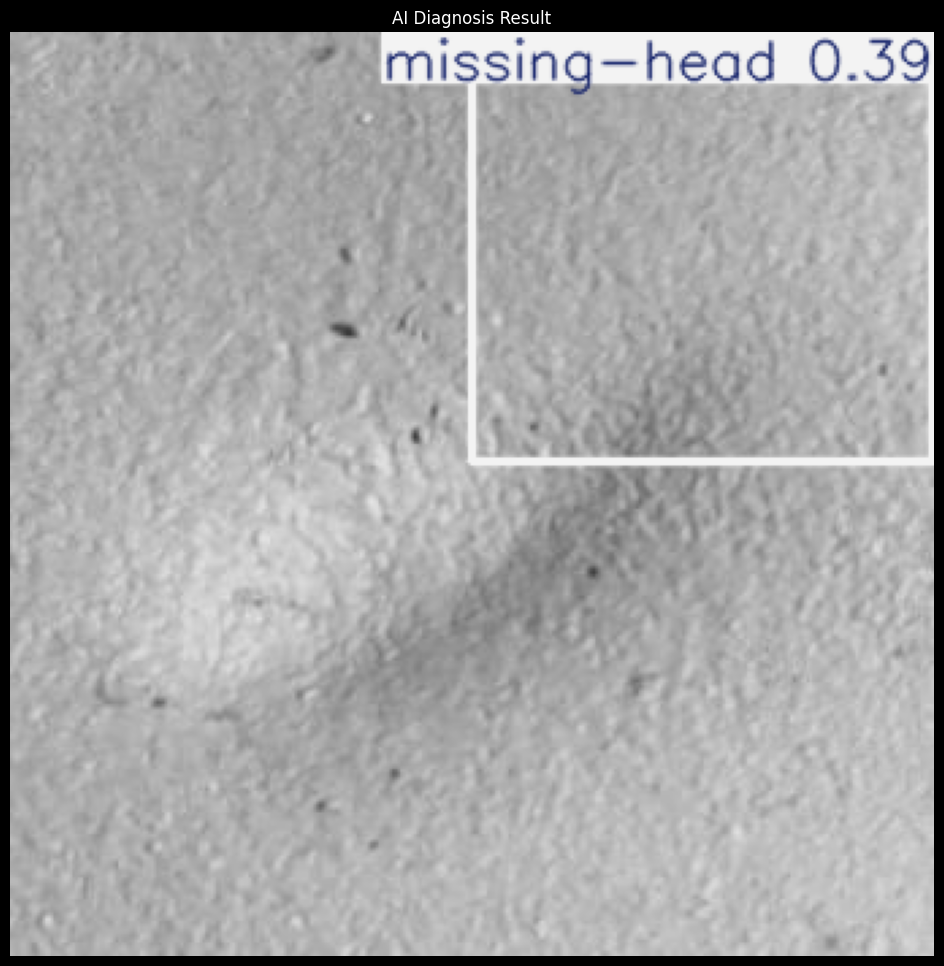

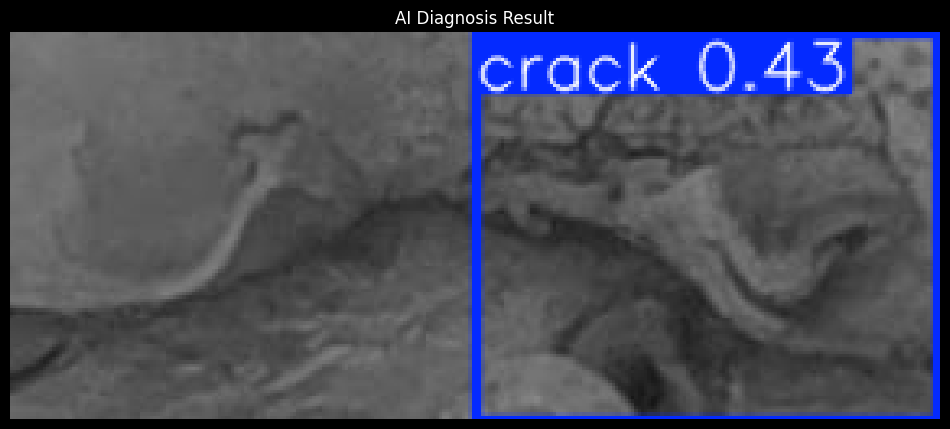

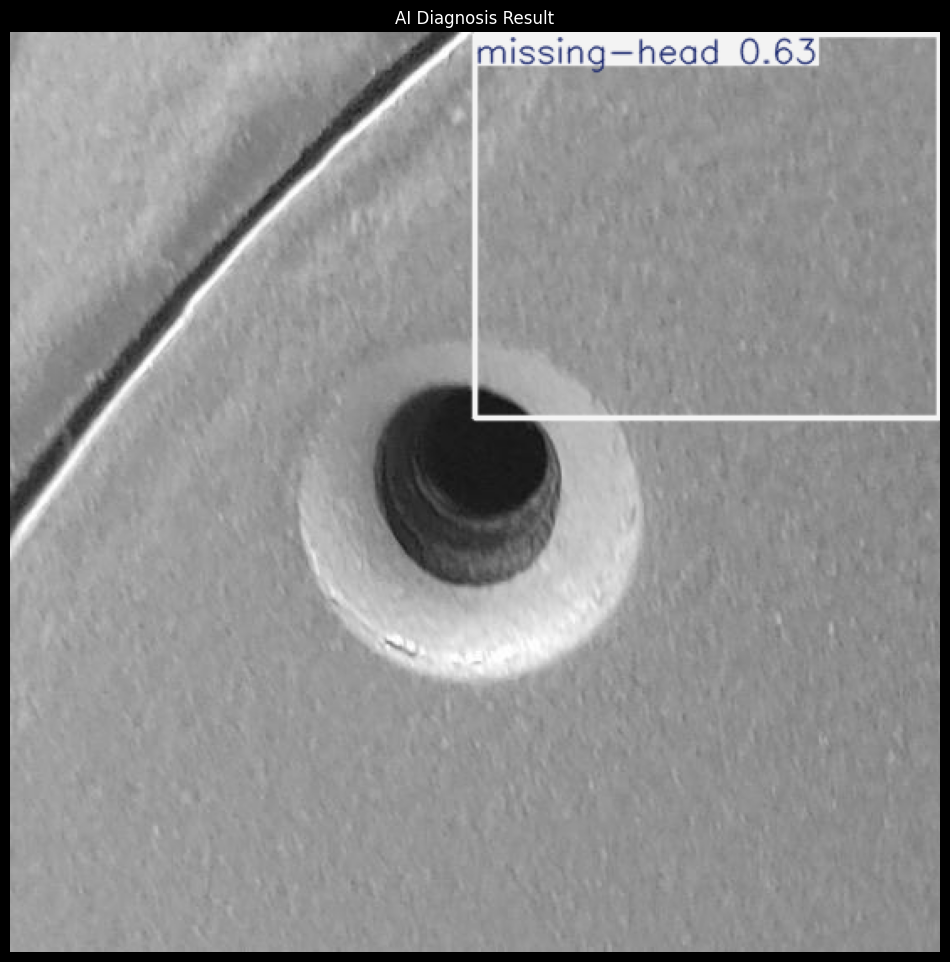

In [12]:
# 1. Load the BEST version of the model (saved during training)
best_model_path = 'runs/detect/yolov8_aircraft_test/weights/best.pt'
model = YOLO(best_model_path)

# 2. Get a list of test images
import glob
test_images = glob.glob("aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8/test/images/*.jpg") # Finds all.jpg files in the test folder

# 3. Pick 3 random images to show
if len(test_images) > 0:
    selected_images = random.sample(test_images, min(3, len(test_images)))
    
    # 4. Run the Prediction
    # conf=0.25: The AI must be at least 25% sure to draw a box.
    # save=True: Save the resulting image with drawn boxes.
    results = model.predict(selected_images, conf=0.25, imgsz=1280, save=True)
    
    # 5. Show the results
    for result in results:
        # Plot the result (draw the boxes on the image array)
        im_array = result.plot()
        
        plt.figure(figsize=(12, 12))
        plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title("AI Diagnosis Result")
        plt.show()
else:
    print("No images found in test/images. Check the folder path.")

### CELL 8: FINAL ACCURACY AND SCORES

Evaluating the model on the validation set...
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 118.5±121.7 MB/s, size: 22.8 KB)
val: Scanning /home/akash/Project Exhibition/YOLOv8 (New)/aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8/valid/labels.cache... 148 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 148/148 62.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.0it/s 3.3s.2ss
                   all        148        148      0.981      0.948       0.99       0.99
                 crack         43         43      0.988      0.953      0.986      0.986
                  dent         46         46      0.985      0.913      0.993      0.993
          missing-head         27      

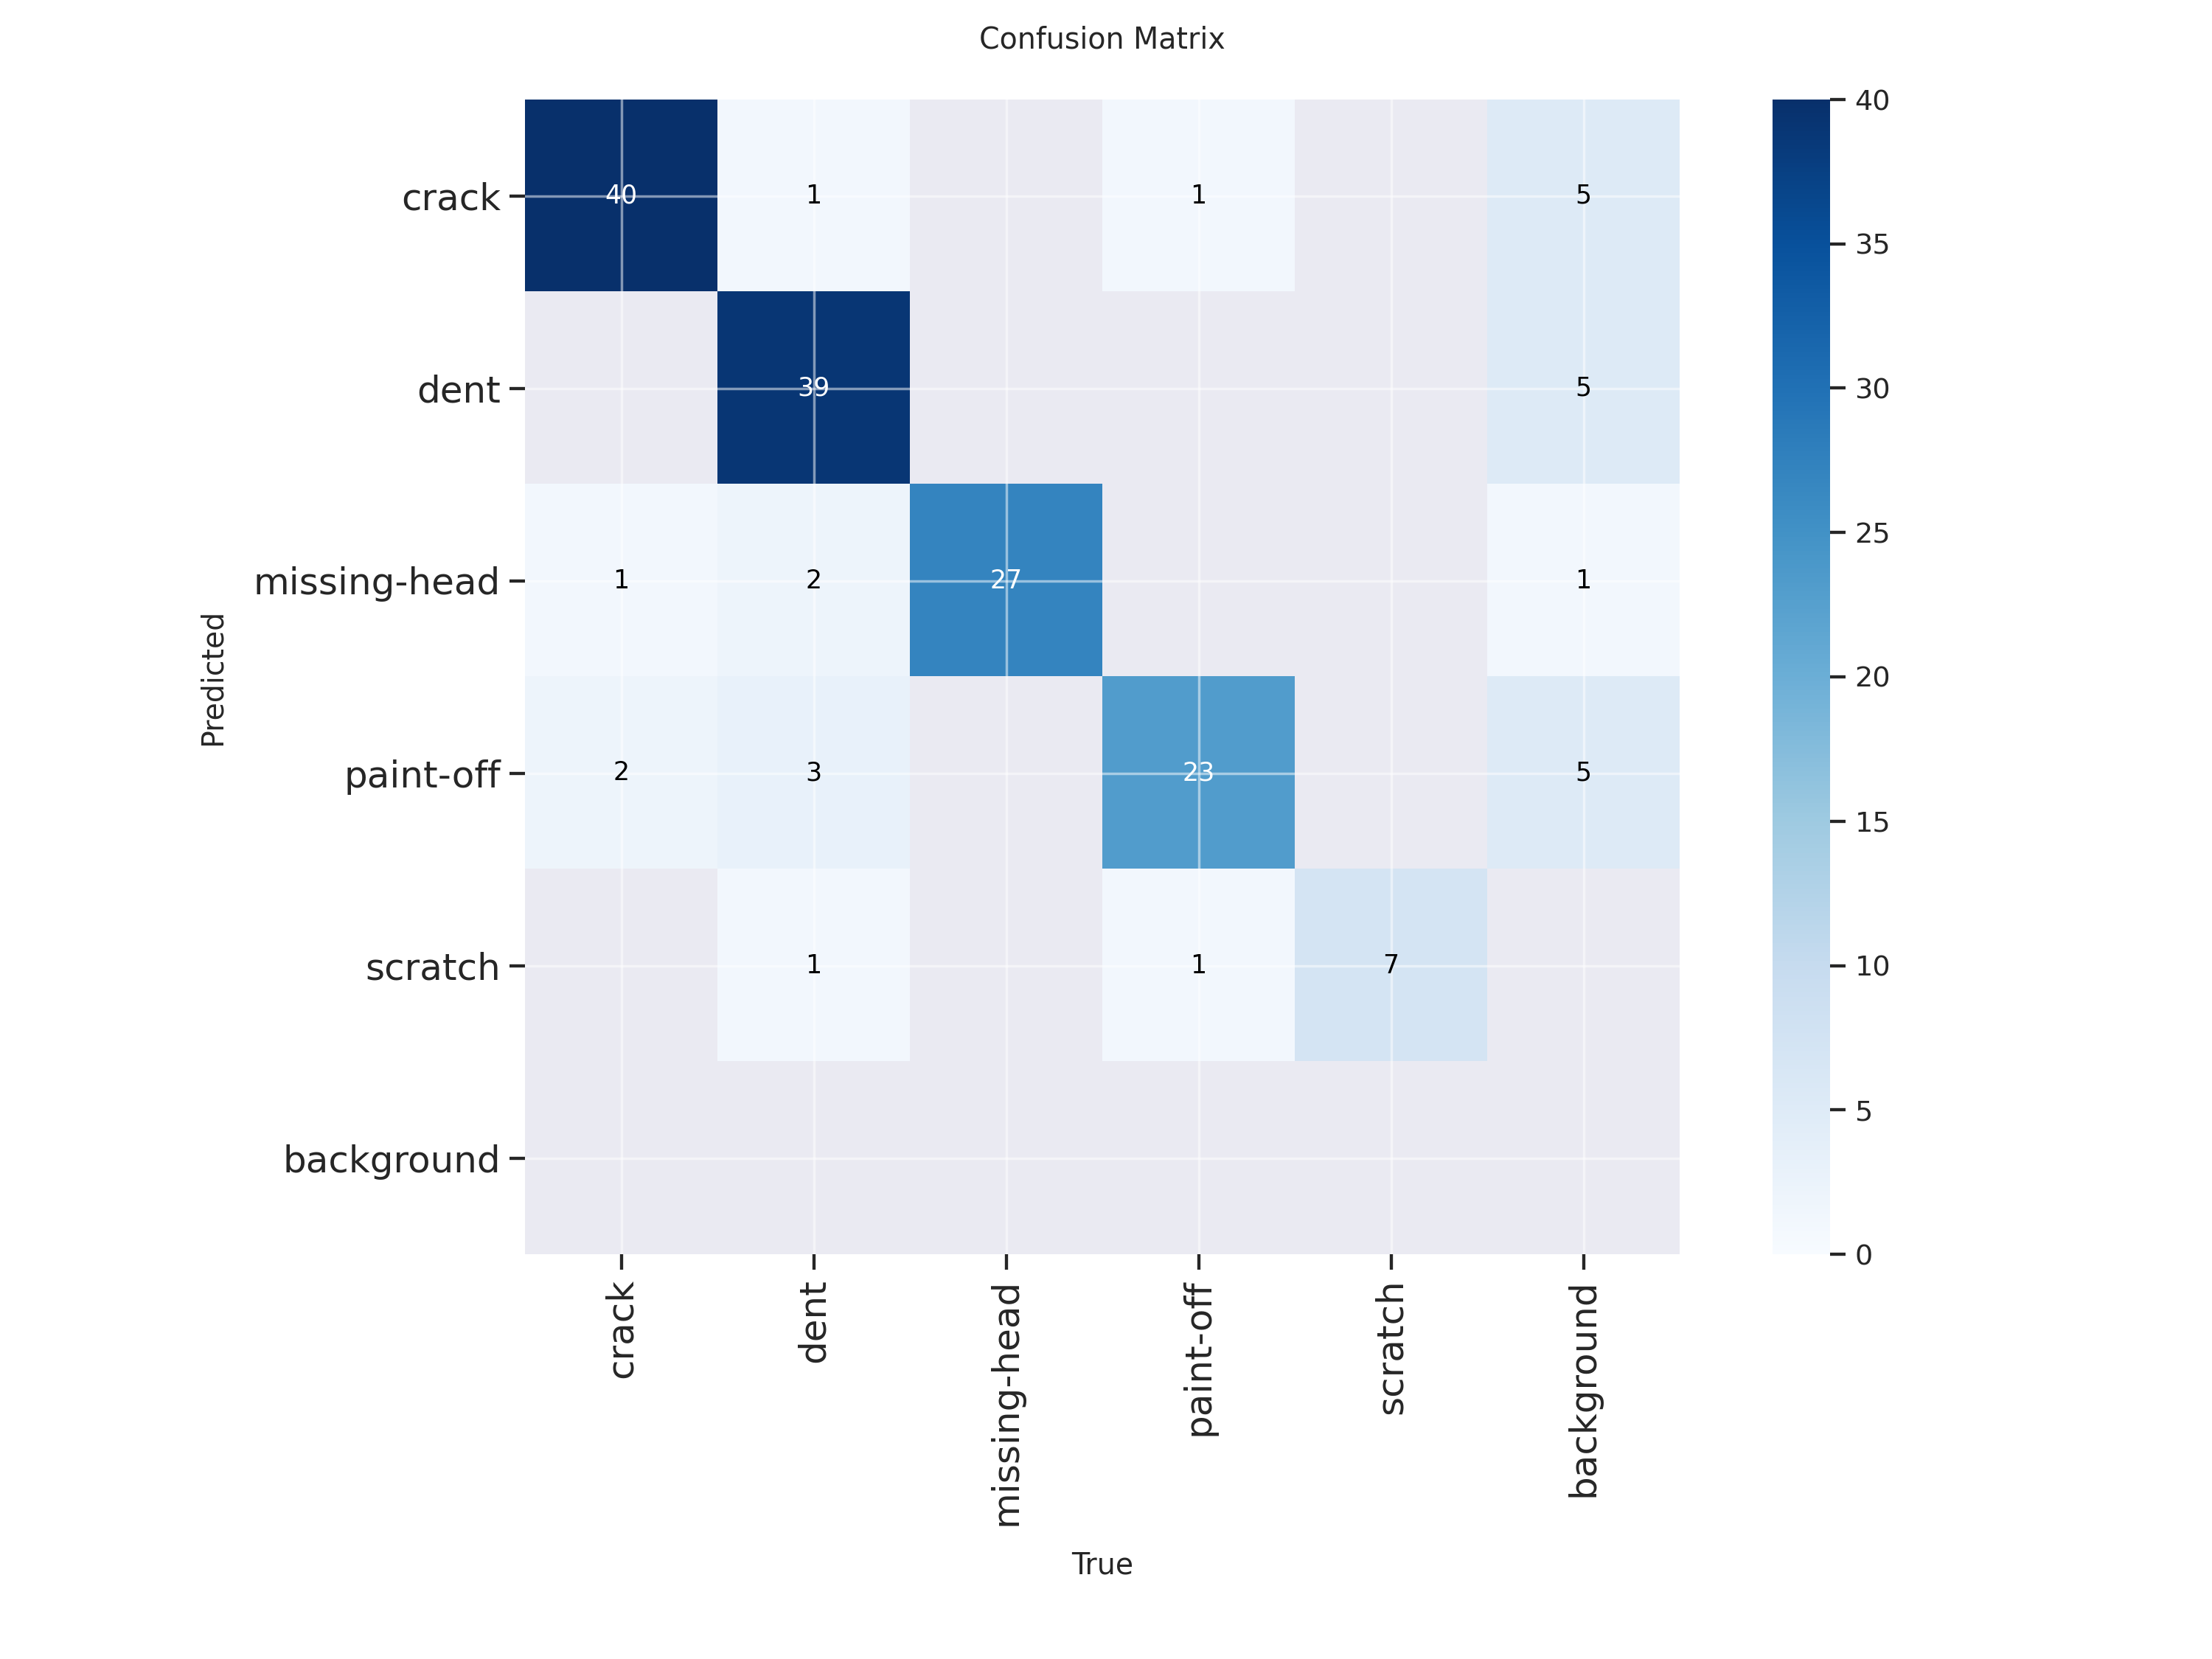

In [ ]:
from IPython.display import Image, display
sns.set_theme()

# 1. Run validation to calculate evaluation metrics
print("Evaluating the model on the validation set...")

# FIX 1: Load YOUR trained model, not the base yolov8s.pt model
model = YOLO('runs/detect/yolov8_aircraft_test/weights/best.pt') 

# FIX 2: Explicitly tell it to validate using YOUR dataset configuration
metrics = model.val(data='aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8/data.yaml') 

# Extract Precision and Recall
precision = metrics.box.mp
recall = metrics.box.mr

# Calculate F1 Score (Harmonic mean of Precision and Recall)
if (precision + recall) > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0.0

# 2. Print numeric evaluation metrics
print("\n--- Numeric Evaluation Metrics ---")
print(f"Mean Precision: {precision:.4f}")
print(f"Mean Recall:    {recall:.4f}")
print(f"F1-Score:       {f1_score:.4f}")
print(f"mAP50:          {metrics.box.map50:.4f}  <-- (Use this as your general 'Accuracy' metric)")
print(f"mAP50-95:       {metrics.box.map:.4f}")

print("\n*Note on Accuracy*: In Object Detection, standard 'Accuracy' (True Positives / Total) is generally replaced by mAP and F1-Score because the model must predict both the class AND the bounding box location. mAP50 is the industry standard proxy for object detection 'accuracy'.")

# 3. Locate and display the Evaluation Matrix (Confusion Matrix)
confusion_matrix_path = os.path.join(metrics.save_dir, 'confusion_matrix.png')

if os.path.exists(confusion_matrix_path):
    print("\n--- Evaluation Matrix (Confusion Matrix) ---")
    display(Image(filename=confusion_matrix_path, width=800))
else:
    print(f"\nConfusion matrix image not found at {confusion_matrix_path}")